In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 24

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 24
there are 44 non_grid and non_spatial_cells
there are 23 grid_cells
there are 40 non grid spatial cells
there are 4 non spatial cells
there are 2 speed cells
there are 69 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 4 modules with HDBSCAN for mouse 25 day 24
for each module , the number of points is: [ 1  5  4 13]


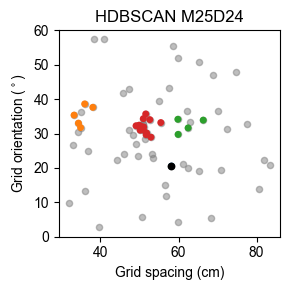

for module 0, there are 5 cells with average spacing 35.305404003465775
for module 1, there are 4 cells with average spacing 62.127313214275674
for module 2, there are 13 cells with average spacing 51.44469907502155
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
25 24
for module 0, there are 5 cells
for module 2, there are 13 cells
for module 1, there are 4 cells


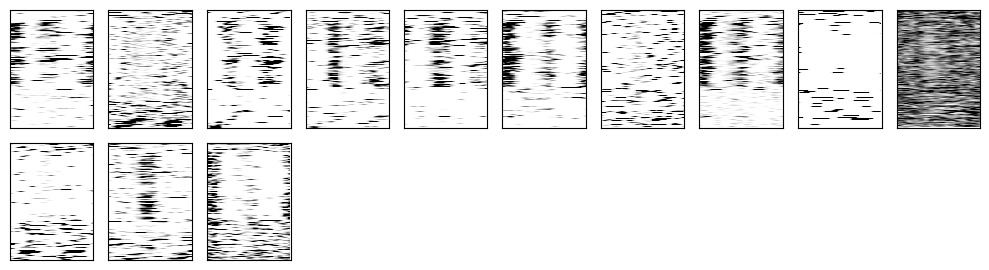

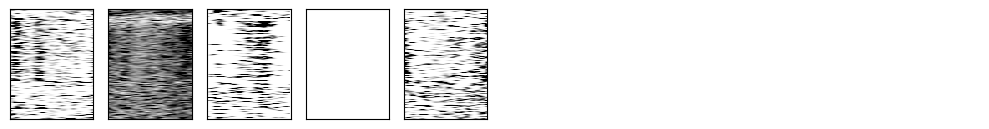

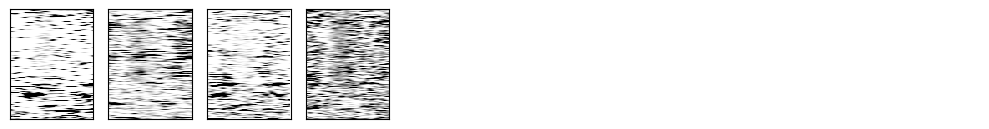

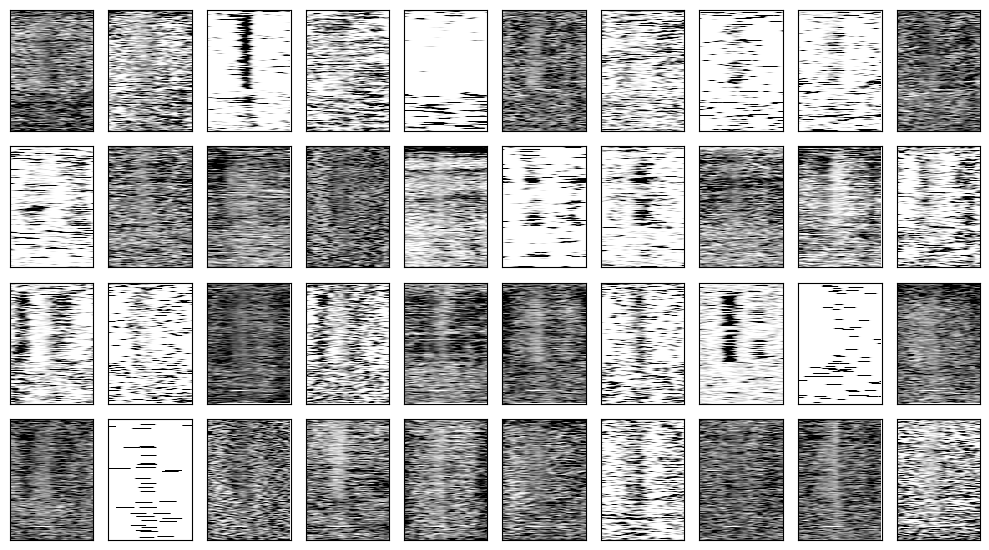

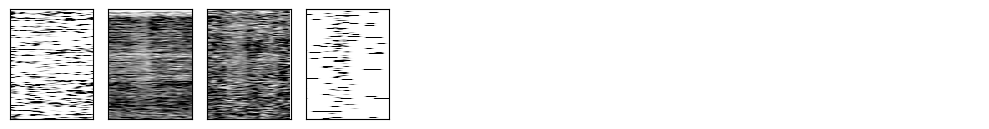

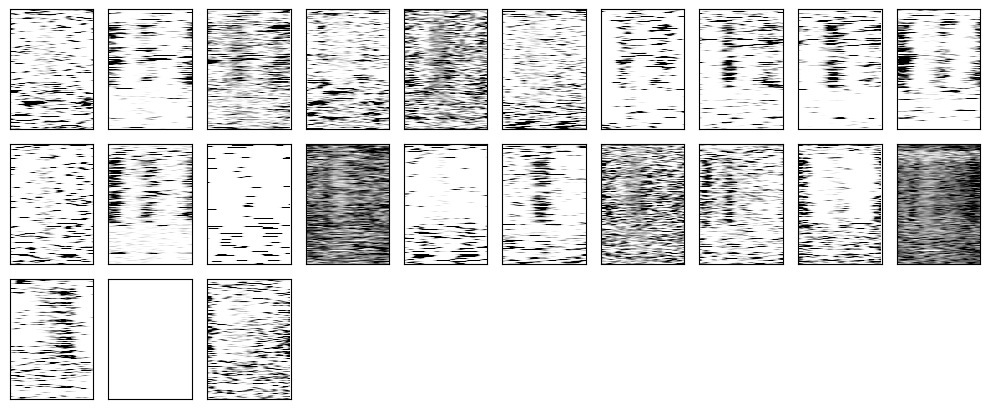

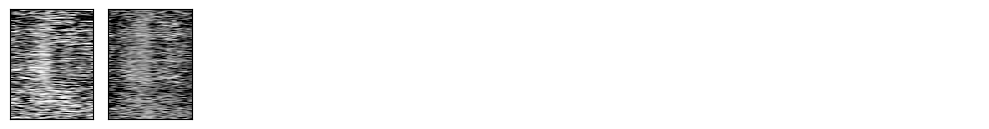

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

tcs,tcs_time,_,_,_,_ = compute_vr_tcs(mouse, day)


Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


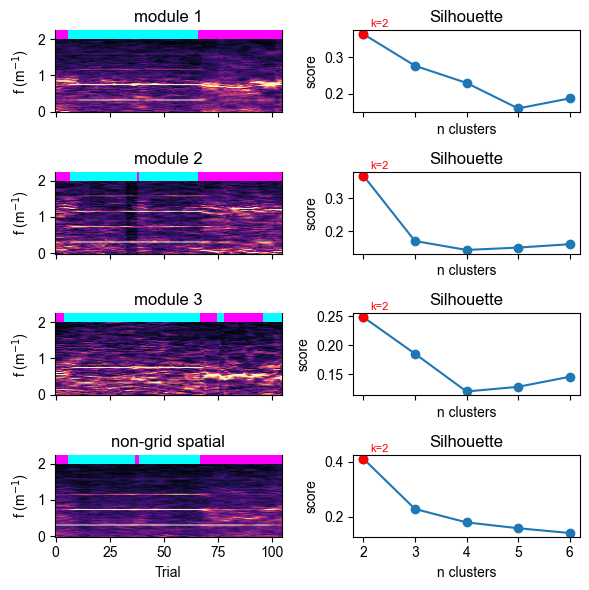

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

fig, ax = plt.subplots(
    nrows=len(g_m_cluster_ids)+1,
    ncols=2,
    figsize=(6, 6),
    squeeze=False,
    sharex='col'
)

def plot_silhouette_metrics(S, ax_silhouette, max_k=6):
    sil_scores = []
    K_range = range(2, max_k+1)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
        labels = kmeans.fit_predict(S.T)
        sil = silhouette_score(S.T, labels)
        sil_scores.append(sil)
    # Silhouette plot
    ax_silhouette.plot(K_range, sil_scores, marker='o')
    ax_silhouette.set_title('Silhouette')
    ax_silhouette.set_xlabel('n clusters')
    ax_silhouette.set_ylabel('score')
    # Mark optimal k (max silhouette)
    best_k_sil = K_range[np.argmax(sil_scores)]
    best_sil = np.max(sil_scores)
    ax_silhouette.plot(best_k_sil, best_sil, 'ro')
    ax_silhouette.annotate(f'k={best_k_sil}', (best_k_sil, best_sil), textcoords="offset points", xytext=(5,5), ha='left', color='red', fontsize=8)

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    # Spectrogram
    ax[m,0].set_title(f'module {m+1}')
    ax[m,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
    ax[m,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[m,0].set_ylabel(r'f (m$^{-1}$)')
    # Hide top spine for clarity
    ax[m,0].spines['top'].set_visible(False)
    # KMeans clusters (k=2)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(S.T)
    # Plot cluster labels just above the top axis spine
    ax[m,0].scatter(
        np.arange(S.shape[1]),
        np.full(S.shape[1], 81),  # y just above the top
        c=labels,
        cmap='cool',
        marker='s',
        s=50,
        edgecolor='none',
        clip_on=True
    )
    plot_silhouette_metrics(S, ax[m,1])

# Non-grid spatial row
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
ax[-1,0].set_title(f'non-grid spatial')
ax[-1,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
ax[-1,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
ax[-1,0].set_ylabel(r'f (m$^{-1}$)')
ax[-1,0].set_xlabel('Trial')
ax[-1,0].spines['top'].set_visible(False)
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
labels = kmeans.fit_predict(S.T)
ax[-1,0].scatter(
    np.arange(S.shape[1]),
    np.full(S.shape[1], 81),
    c=labels,
    cmap='cool',
    marker='s',
    s=50,
    edgecolor='none',
    clip_on=True
)
plot_silhouette_metrics(S, ax[-1,1])

plt.tight_layout()
plt.show()

we can see from this example session that k=2 is fairly common. We can compute this for all sessions. For all cell group joint spectrograms, we can compute the optimal k and plot this against the number of units used to create the spectrogram. This would be a good test just in case groups with low cell numbers have high k clusters because of the increased variability

20 14
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (76, 105)


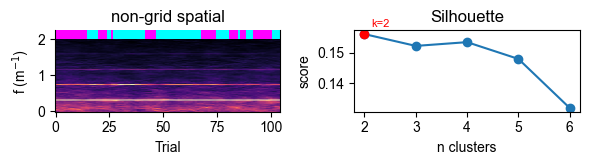

20 16
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 16
for each module , the number of points is: [3]


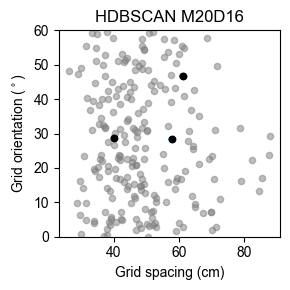

Identified 1 candidate modules
shape of S: (76, 189)


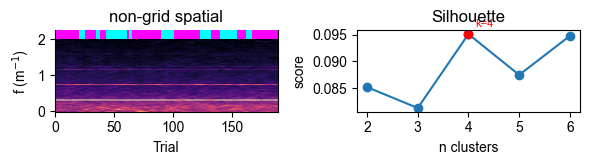

20 17
there are 112 non_grid and non_spatial_cells
there are 3 grid_cells
there are 88 non grid spatial cells
there are 24 non spatial cells
there are 17 speed cells
there are 132 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 17
for each module , the number of points is: [3]


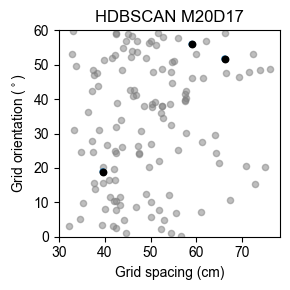

Identified 1 candidate modules
shape of S: (76, 146)


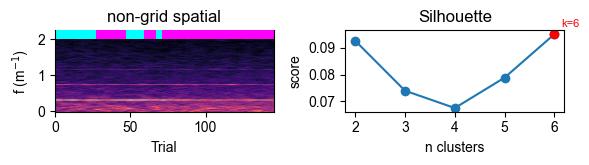

20 18
there are 139 non_grid and non_spatial_cells
there are 1 grid_cells
there are 105 non grid spatial cells
there are 34 non spatial cells
there are 11 speed cells
there are 151 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (76, 177)


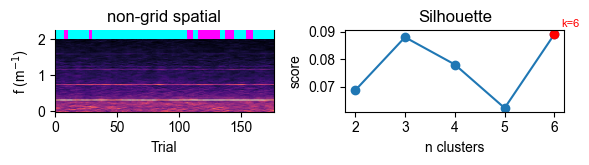

20 19
there are 111 non_grid and non_spatial_cells
there are 1 grid_cells
there are 92 non grid spatial cells
there are 19 non spatial cells
there are 5 speed cells
there are 117 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (76, 181)


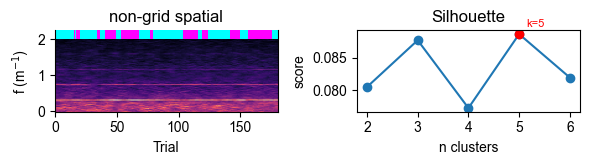

20 20
there are 89 non_grid and non_spatial_cells
there are 4 grid_cells
there are 78 non grid spatial cells
there are 11 non spatial cells
there are 10 speed cells
there are 103 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 20
for each module , the number of points is: [4]


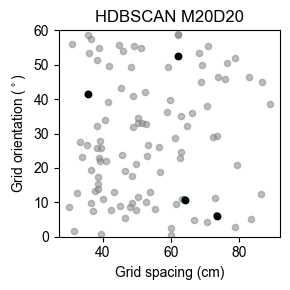

Identified 1 candidate modules
shape of S: (76, 176)


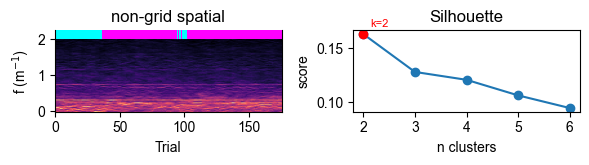

20 21
there are 111 non_grid and non_spatial_cells
there are 0 grid_cells
there are 69 non grid spatial cells
there are 42 non spatial cells
there are 5 speed cells
there are 116 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (76, 179)


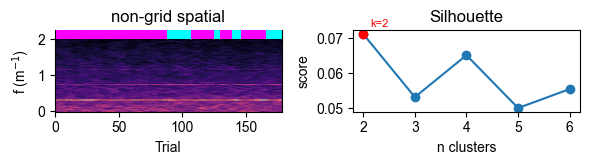

20 22
there are 73 non_grid and non_spatial_cells
there are 3 grid_cells
there are 70 non grid spatial cells
there are 3 non spatial cells
there are 4 speed cells
there are 80 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 22
for each module , the number of points is: [3]


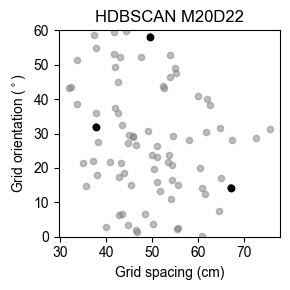

Identified 1 candidate modules
shape of S: (76, 189)


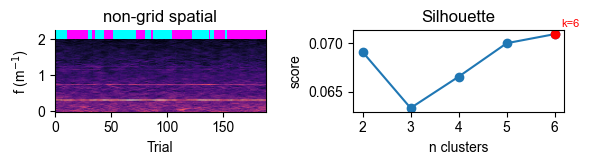

20 23
there are 66 non_grid and non_spatial_cells
there are 3 grid_cells
there are 51 non grid spatial cells
there are 15 non spatial cells
there are 16 speed cells
there are 85 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 23
for each module , the number of points is: [3]


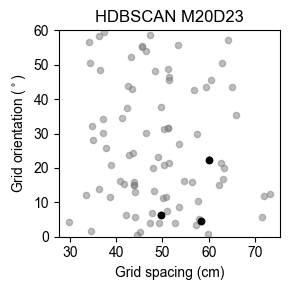

Identified 1 candidate modules
shape of S: (76, 150)


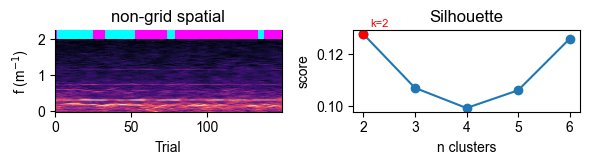

20 24
there are 77 non_grid and non_spatial_cells
there are 2 grid_cells
there are 67 non grid spatial cells
there are 10 non spatial cells
there are 1 speed cells
there are 80 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 24
for each module , the number of points is: [2]


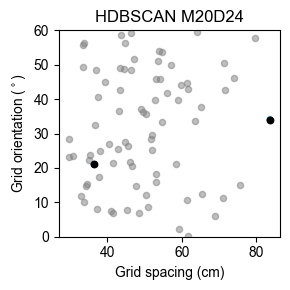

Identified 1 candidate modules
shape of S: (76, 199)


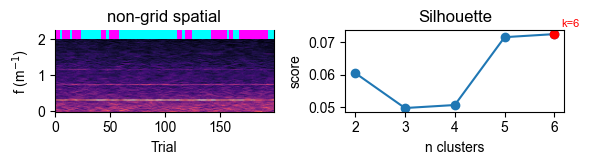

20 25
there are 24 non_grid and non_spatial_cells
there are 11 grid_cells
there are 18 non grid spatial cells
there are 6 non spatial cells
there are 1 speed cells
there are 36 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 2 modules with HDBSCAN for mouse 20 day 25
for each module , the number of points is: [4 7]


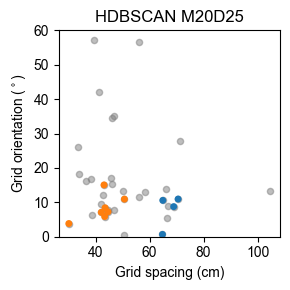

for module 0, there are 4 cells with average spacing 67.28909384604304
for module 1, there are 7 cells with average spacing 42.497564765534584
module 1 contains cells from ['ENTm3']
module 0 contains cells from ['ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 190)


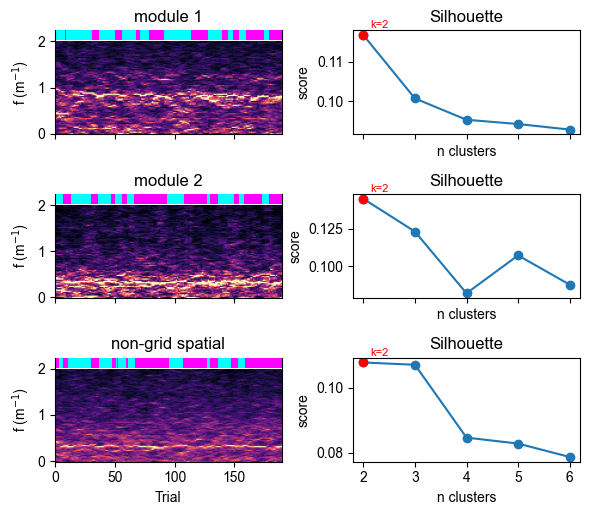

20 26
there are 133 non_grid and non_spatial_cells
there are 2 grid_cells
there are 96 non grid spatial cells
there are 37 non spatial cells
there are 19 speed cells
there are 154 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 26
for each module , the number of points is: [2]


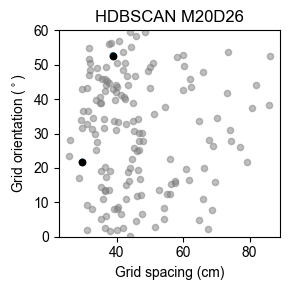

Identified 1 candidate modules
shape of S: (76, 196)


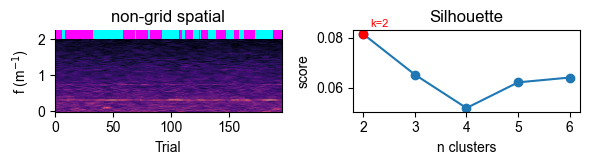

21 15
there are 181 non_grid and non_spatial_cells
there are 3 grid_cells
there are 168 non grid spatial cells
there are 13 non spatial cells
there are 58 speed cells
there are 242 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 15
for each module , the number of points is: [3]


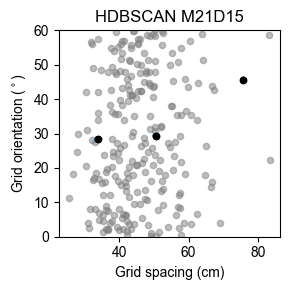

Identified 1 candidate modules
shape of S: (76, 35)


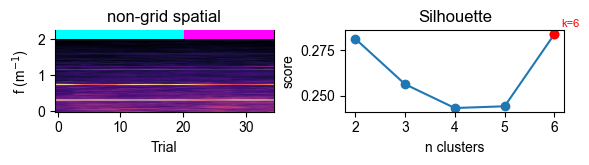

21 16
there are 194 non_grid and non_spatial_cells
there are 17 grid_cells
there are 173 non grid spatial cells
there are 21 non spatial cells
there are 29 speed cells
there are 240 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 4 modules with HDBSCAN for mouse 21 day 16
for each module , the number of points is: [ 1  3  3 10]


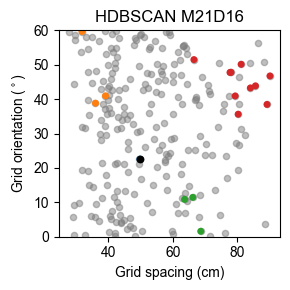

for module 0, there are 3 cells with average spacing 35.63117488281154
for module 1, there are 3 cells with average spacing 66.15685817796435
for module 2, there are 10 cells with average spacing 81.22485030108808
module 0 contains cells from ['ENTm5' 'ENTm6']
module 1 contains cells from ['ENTm2' 'ENTm6']
module 2 contains cells from ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm6']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 43)


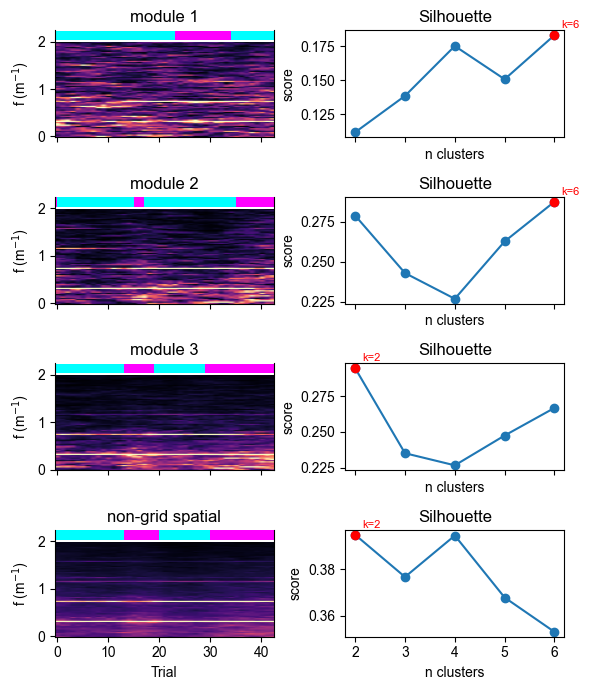

21 17
there are 215 non_grid and non_spatial_cells
there are 4 grid_cells
there are 187 non grid spatial cells
there are 28 non spatial cells
there are 45 speed cells
there are 264 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 17
for each module , the number of points is: [4]


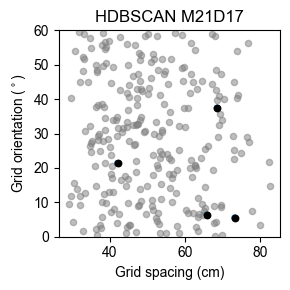

Identified 1 candidate modules
shape of S: (76, 45)


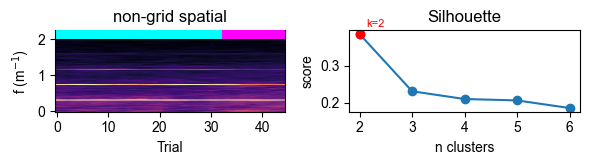

21 18
there are 149 non_grid and non_spatial_cells
there are 3 grid_cells
there are 132 non grid spatial cells
there are 17 non spatial cells
there are 34 speed cells
there are 186 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 18
for each module , the number of points is: [3]


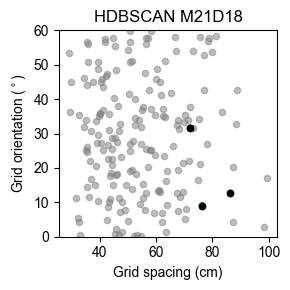

Identified 1 candidate modules
shape of S: (76, 58)


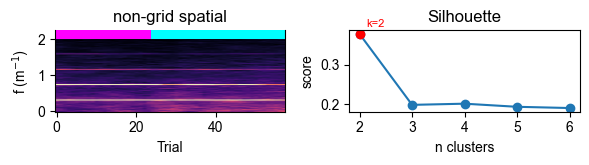

21 19
there are 371 non_grid and non_spatial_cells
there are 7 grid_cells
there are 324 non grid spatial cells
there are 47 non spatial cells
there are 35 speed cells
there are 413 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 19
for each module , the number of points is: [7]


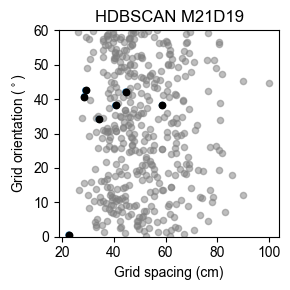

Identified 1 candidate modules
shape of S: (76, 47)


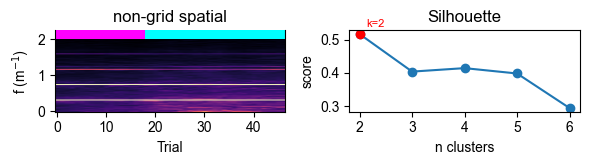

21 20
there are 290 non_grid and non_spatial_cells
there are 7 grid_cells
there are 243 non grid spatial cells
there are 47 non spatial cells
there are 29 speed cells
there are 326 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 2 modules with HDBSCAN for mouse 21 day 20
for each module , the number of points is: [3 4]


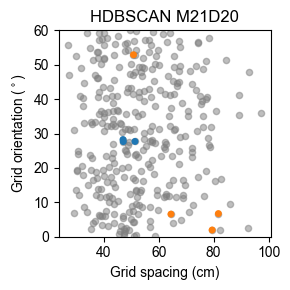

for module 0, there are 3 cells with average spacing 48.47526051620829
for module 1, there are 4 cells with average spacing 69.10889839184068
module 0 contains cells from ['ENTm6' 'VISpor6a']
module 1 contains cells from ['ENTm6']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 53)


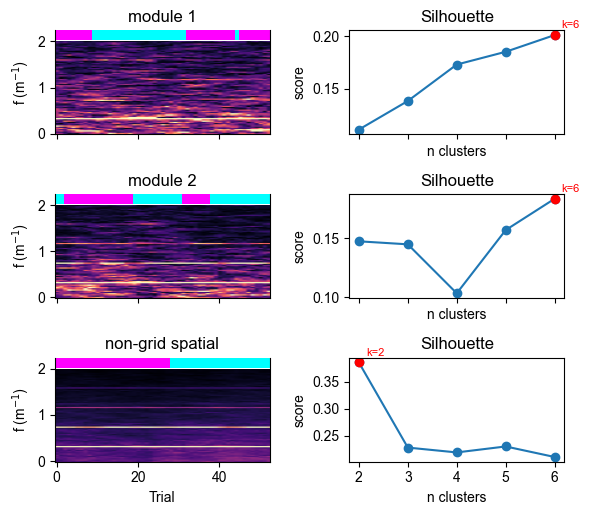

21 21
there are 246 non_grid and non_spatial_cells
there are 39 grid_cells
there are 186 non grid spatial cells
there are 60 non spatial cells
there are 30 speed cells
there are 315 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 4 modules with HDBSCAN for mouse 21 day 21
for each module , the number of points is: [ 3  3  3 30]


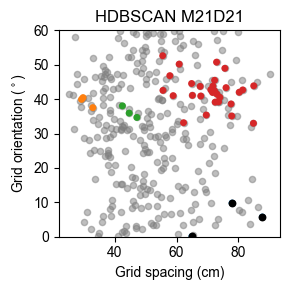

for module 0, there are 3 cells with average spacing 30.63998585780331
for module 1, there are 3 cells with average spacing 44.77260507515509
for module 2, there are 30 cells with average spacing 70.78125582859651
module 0 contains cells from ['ENTm6' 'HPF' 'VISl6a']
module 1 contains cells from ['ENTm5' 'HPF']
module 2 contains cells from ['ENTm1' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 77)


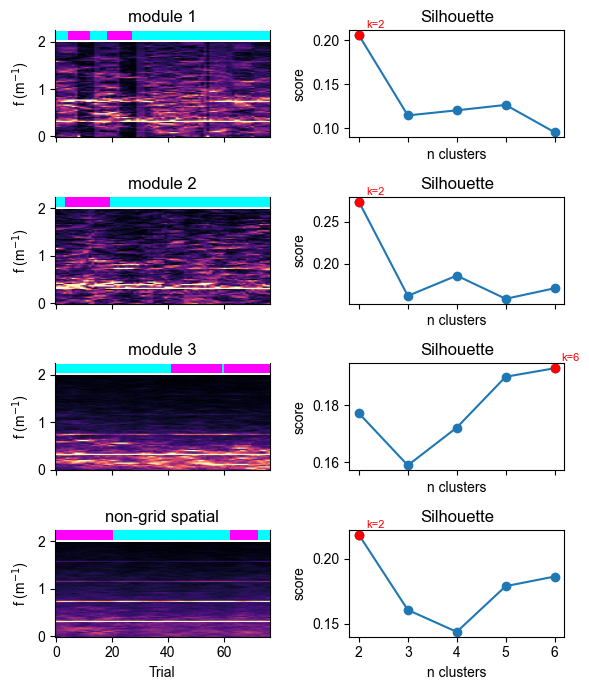

21 22
there are 127 non_grid and non_spatial_cells
there are 2 grid_cells
there are 83 non grid spatial cells
there are 44 non spatial cells
there are 12 speed cells
there are 141 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 22
for each module , the number of points is: [2]


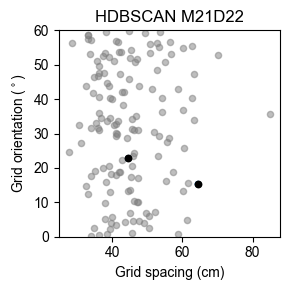

Identified 1 candidate modules
shape of S: (76, 91)


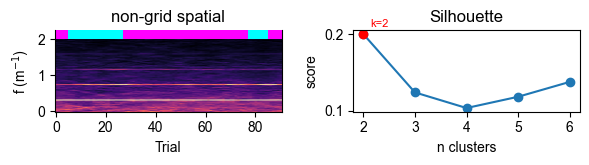

21 23
there are 321 non_grid and non_spatial_cells
there are 3 grid_cells
there are 271 non grid spatial cells
there are 50 non spatial cells
there are 20 speed cells
there are 344 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 23
for each module , the number of points is: [3]


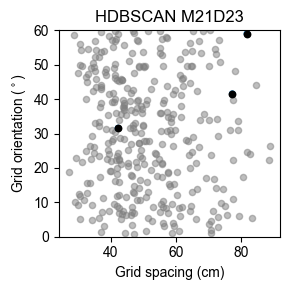

Identified 1 candidate modules
shape of S: (76, 128)


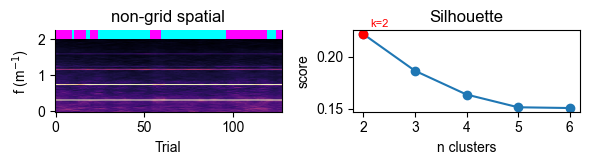

21 24
there are 206 non_grid and non_spatial_cells
there are 5 grid_cells
there are 170 non grid spatial cells
there are 36 non spatial cells
there are 7 speed cells
there are 218 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 24
for each module , the number of points is: [5]


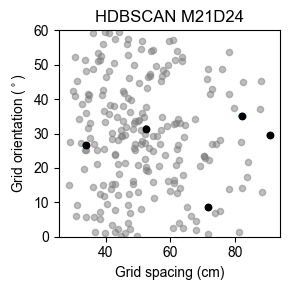

Identified 1 candidate modules
shape of S: (76, 124)


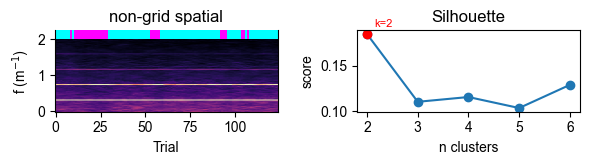

21 25
there are 158 non_grid and non_spatial_cells
there are 8 grid_cells
there are 117 non grid spatial cells
there are 41 non spatial cells
there are 10 speed cells
there are 176 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 2 modules with HDBSCAN for mouse 21 day 25
for each module , the number of points is: [3 5]


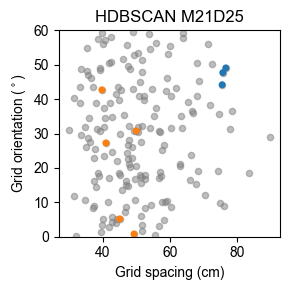

for module 0, there are 3 cells with average spacing 75.96795527689922
for module 1, there are 5 cells with average spacing 45.07035857093305
module 1 contains cells from ['ENTm5' 'VISl1' 'VISpl2/3']
module 0 contains cells from ['ENTm5' 'VISpl4']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 82)


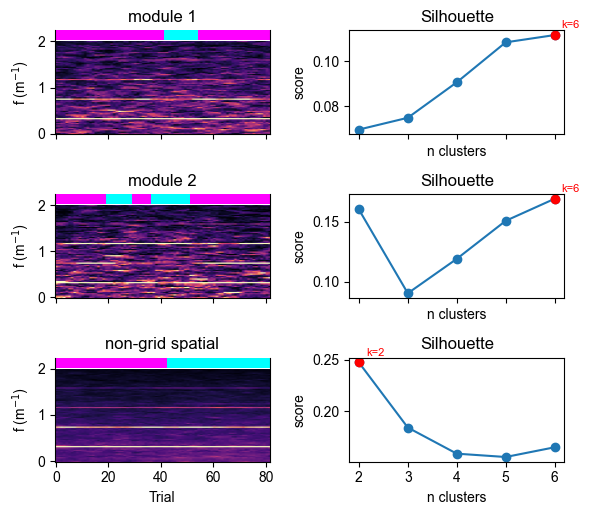

21 26
there are 162 non_grid and non_spatial_cells
there are 24 grid_cells
there are 148 non grid spatial cells
there are 14 non spatial cells
there are 5 speed cells
there are 191 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 4 modules with HDBSCAN for mouse 21 day 26
for each module , the number of points is: [ 5  3  4 12]


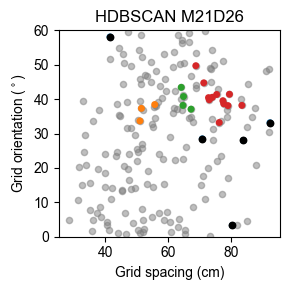

for module 0, there are 3 cells with average spacing 52.704988880266455
for module 1, there are 4 cells with average spacing 65.18358943535513
for module 2, there are 12 cells with average spacing 75.6350825836551
module 0 contains cells from ['ENTm5' 'ENTm6']
module 1 contains cells from ['ENTm3']
module 2 contains cells from ['ENTm2' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 88)


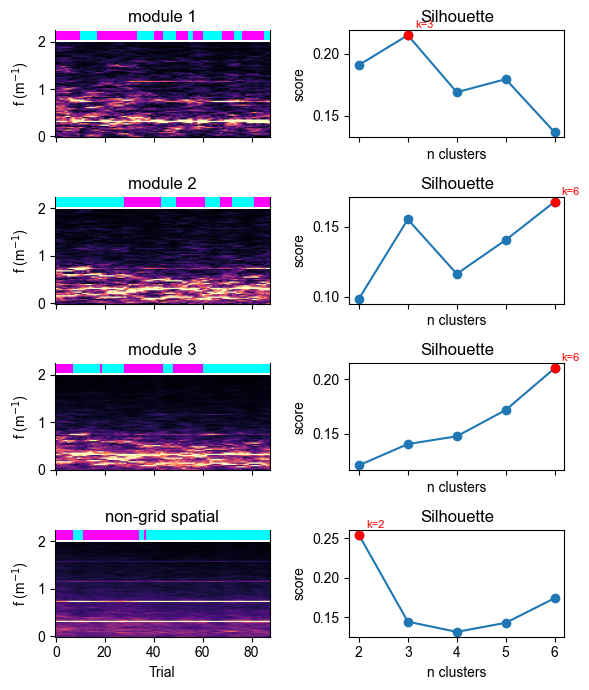

25 16
there are 32 non_grid and non_spatial_cells
there are 1 grid_cells
there are 28 non grid spatial cells
there are 4 non spatial cells
there are 5 speed cells
there are 38 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (76, 129)


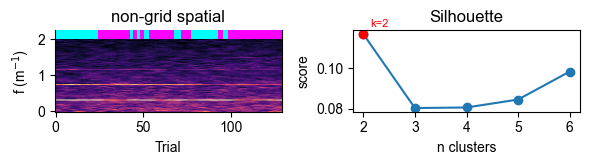

25 17
there are 57 non_grid and non_spatial_cells
there are 1 grid_cells
there are 20 non grid spatial cells
there are 37 non spatial cells
there are 10 speed cells
there are 68 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (76, 74)


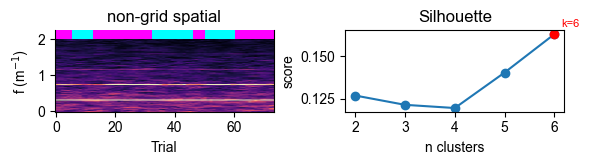

25 18
there are 84 non_grid and non_spatial_cells
there are 6 grid_cells
there are 55 non grid spatial cells
there are 29 non spatial cells
there are 56 speed cells
there are 146 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 25 day 18
for each module , the number of points is: [6]


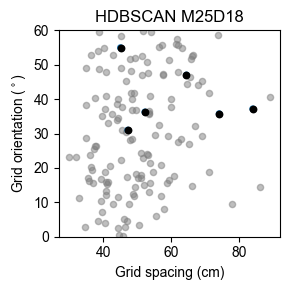

Identified 1 candidate modules
shape of S: (76, 46)


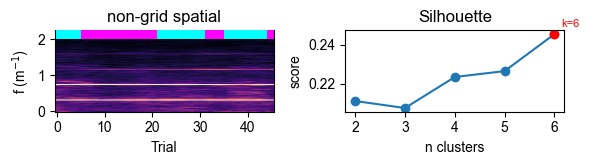

25 19
there are 37 non_grid and non_spatial_cells
there are 12 grid_cells
there are 34 non grid spatial cells
there are 3 non spatial cells
there are 10 speed cells
there are 59 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 3 modules with HDBSCAN for mouse 25 day 19
for each module , the number of points is: [5 3 4]


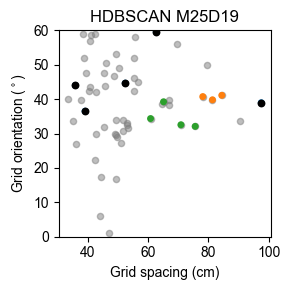

for module 0, there are 3 cells with average spacing 81.34142236534187
for module 1, there are 4 cells with average spacing 68.13287476384306
module 1 contains cells from ['ENTm1' 'ENTm2']
module 0 contains cells from ['ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 84)


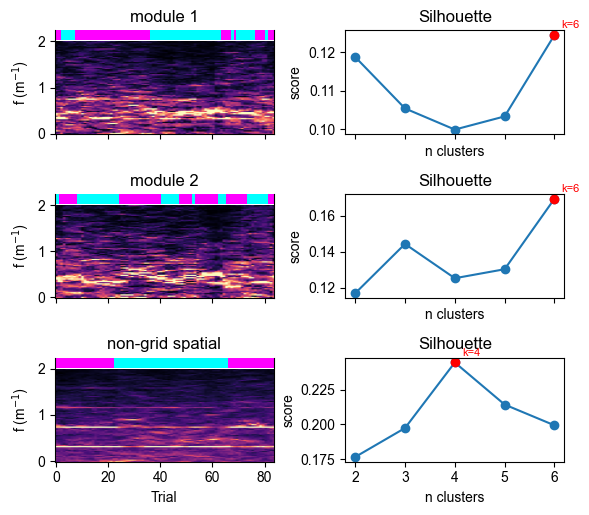

25 20
there are 42 non_grid and non_spatial_cells
there are 13 grid_cells
there are 38 non grid spatial cells
there are 4 non spatial cells
there are 12 speed cells
there are 67 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 3 modules with HDBSCAN for mouse 25 day 20
for each module , the number of points is: [1 3 9]


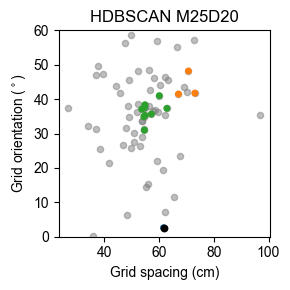

for module 0, there are 3 cells with average spacing 70.3536739667689
for module 1, there are 9 cells with average spacing 56.43120842495008
module 1 contains cells from ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
module 0 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 168)


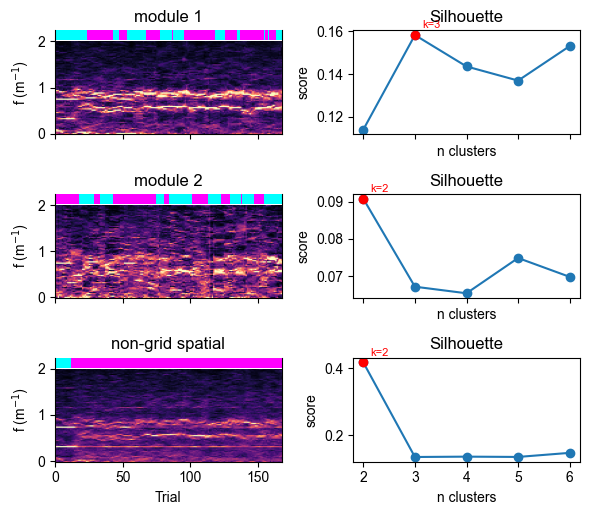

25 21
there are 24 non_grid and non_spatial_cells
there are 24 grid_cells
there are 18 non grid spatial cells
there are 6 non spatial cells
there are 16 speed cells
there are 64 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 3 modules with HDBSCAN for mouse 25 day 21
for each module , the number of points is: [ 4  9 11]


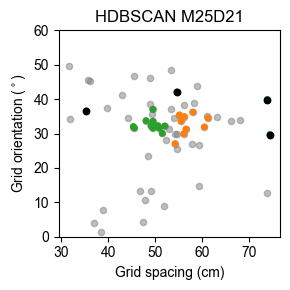

for module 0, there are 9 cells with average spacing 57.03551188796726
for module 1, there are 11 cells with average spacing 49.228056835524015
module 1 contains cells from ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
module 0 contains cells from ['ENTm2' 'PAR' 'VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 128)


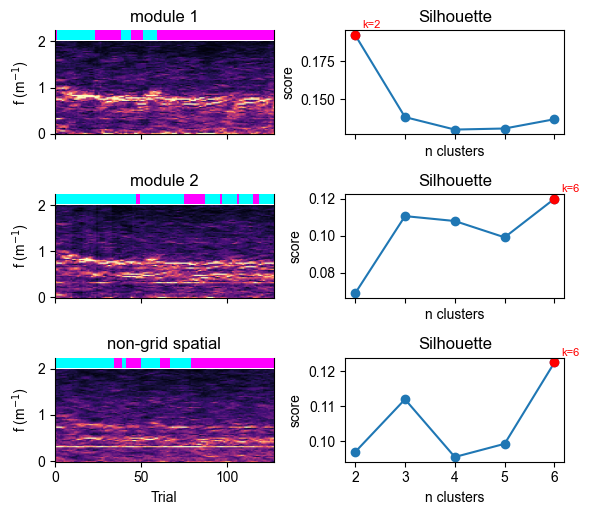

25 22
there are 129 non_grid and non_spatial_cells
there are 9 grid_cells
there are 85 non grid spatial cells
there are 44 non spatial cells
there are 51 speed cells
there are 189 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 2 modules with HDBSCAN for mouse 25 day 22
for each module , the number of points is: [3 6]


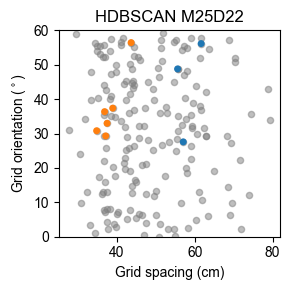

for module 0, there are 3 cells with average spacing 58.08447061582839
for module 1, there are 6 cells with average spacing 38.111269894827124
module 1 contains cells from ['ENTm1' 'VISp2/3' 'VISpl5']
module 0 contains cells from ['ENTm2' 'ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 66)


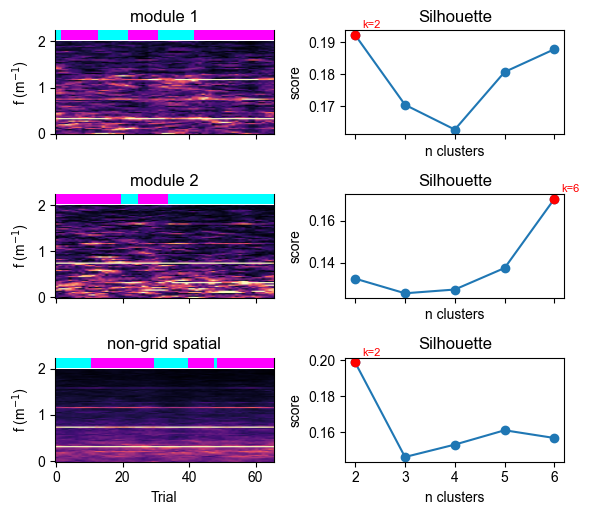

25 23
there are 193 non_grid and non_spatial_cells
there are 4 grid_cells
there are 113 non grid spatial cells
there are 80 non spatial cells
there are 30 speed cells
there are 227 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 25 day 23
for each module , the number of points is: [4]


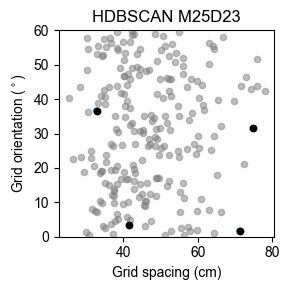

Identified 1 candidate modules
shape of S: (76, 94)


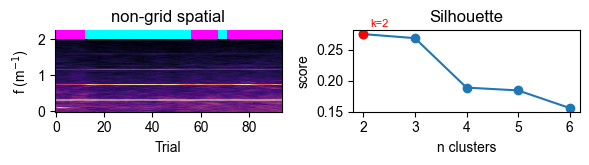

25 24
there are 44 non_grid and non_spatial_cells
there are 23 grid_cells
there are 40 non grid spatial cells
there are 4 non spatial cells
there are 2 speed cells
there are 69 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 4 modules with HDBSCAN for mouse 25 day 24
for each module , the number of points is: [ 1  5  4 13]


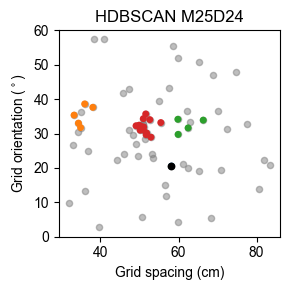

for module 0, there are 5 cells with average spacing 35.305404003465775
for module 1, there are 4 cells with average spacing 62.127313214275674
for module 2, there are 13 cells with average spacing 51.44469907502155
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 105)


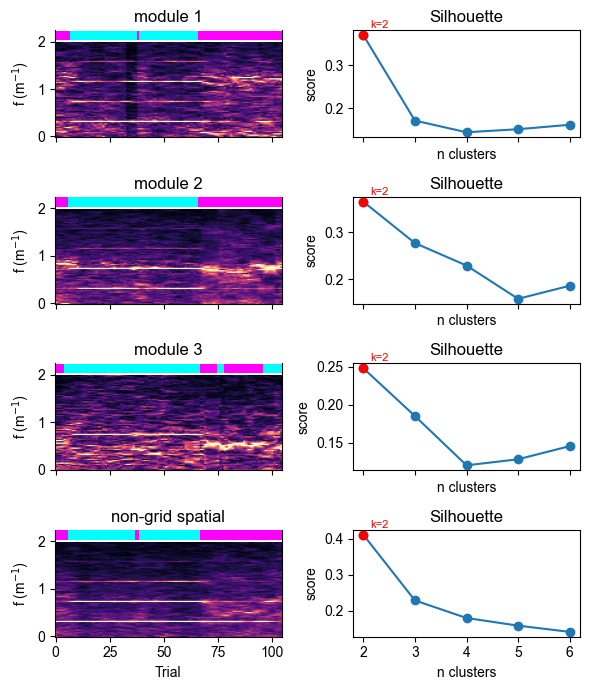

25 25
there are 92 non_grid and non_spatial_cells
there are 39 grid_cells
there are 78 non grid spatial cells
there are 14 non spatial cells
there are 21 speed cells
there are 152 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 3  3 33]


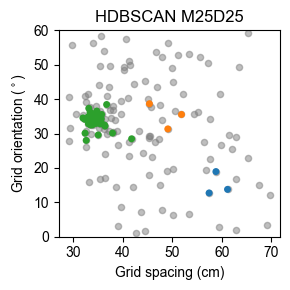

for module 0, there are 3 cells with average spacing 59.12650752692819
for module 1, there are 3 cells with average spacing 48.79472288460559
for module 2, there are 33 cells with average spacing 34.66376365589035
module 2 contains cells from ['VISp2/3' 'VISpl2/3' 'VISpl4' 'VISpl5']
module 1 contains cells from ['VISpl2/3' 'VISpl4' 'VISpl5']
module 0 contains cells from ['VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (76, 102)


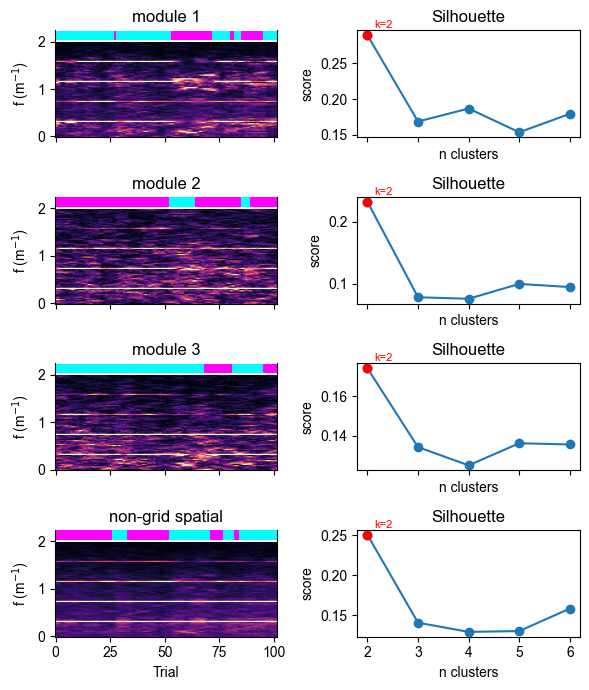

FileNotFoundError: File /Users/harryclark/Downloads/COHORT12/M25/D26/VR/sub-25_day-26_ses-VR_beh.nwb does not exist

In [ ]:
mouse_days = {20: [14,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19,20,21,22,23],
              27: [16,17,18,19,20,21,22,23,24,25,26],
              28: [16,17,18,19,20,21,22,23,24],
              29: [16,17,18,19,20,21,22,23],
            }

gcs_optimal_k = []
gcs_number_of_units = []
ngs_optimal_k = []
ngs_number_of_units = []
for mouse, days in mouse_days.items():
    for day in days:
        tcs, tcs_time, _, _, _, _ = compute_vr_tcs(mouse, day)

        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)
        # Grid cells
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True)
        
        fig, ax = plt.subplots(
            nrows=len(g_m_cluster_ids)+1,
            ncols=2,
            figsize=(6, (len(g_m_cluster_ids)+1)*1.75),
            squeeze=False,
            sharex='col'
        )
        
        for m, cluster_ids in enumerate(g_m_cluster_ids):
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3] 
            S = spectrograms.mean(0)
            # KMeans clusters (k=2)
            kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
            labels = kmeans.fit_predict(S.T)
            sil_score = silhouette_score(S.T, labels)
            gcs_optimal_k.append(len(cluster_ids))
            gcs_number_of_units.append(len(tcs_to_use))
            
            # Spectrogram
            ax[m,0].set_title(f'module {m+1}')
            ax[m,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
            ax[m,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
            ax[m,0].set_ylabel(r'f (m$^{-1}$)')
            # Hide top spine for clarity
            ax[m,0].spines['top'].set_visible(False)
            # KMeans clusters (k=2)
            kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
            labels = kmeans.fit_predict(S.T)
            # Plot cluster labels just above the top axis spine
            ax[m,0].scatter(
                np.arange(S.shape[1]),
                np.full(S.shape[1], 81),  # y just above the top
                c=labels,
                cmap='cool',
                marker='s',
                s=50,
                edgecolor='none',
                clip_on=True
            )
            plot_silhouette_metrics(S, ax[m,1])


        # Non-grid spatial cells
        tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3] 
        S = spectrograms.mean(0)
        # KMeans clusters (k=2)
        kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
        labels = kmeans.fit_predict(S.T)
        sil_score = silhouette_score(S.T, labels)
        ngs_optimal_k.append(len(cluster_ids))
        ngs_number_of_units.append(len(tcs_to_use))

        print(f'shape of S: {S.shape}')
        # spectrogram
        ax[-1,0].set_title(f'non-grid spatial')
        ax[-1,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
        ax[-1,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
        ax[-1,0].set_ylabel(r'f (m$^{-1}$)')
        ax[-1,0].set_xlabel('Trial')
        ax[-1,0].spines['top'].set_visible(False)
        kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
        labels = kmeans.fit_predict(S.T)
        ax[-1,0].scatter(
            np.arange(S.shape[1]),
            np.full(S.shape[1], 81),
            c=labels,
            cmap='cool',
            marker='s',
            s=50,
            edgecolor='none',
            clip_on=True
        )
        plot_silhouette_metrics(S, ax[-1,1])
        plt.tight_layout()
        plt.show()


In [ ]:
# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(gcs_number_of_units, gcs_optimal_k, label='Grid Cells', color='#6897CD', alpha=0.5)
plt.scatter(ngs_number_of_units, ngs_optimal_k, label='Non-Grid Spatial Cells', color='#CAC841', alpha=0.5)
plt.title('Optimal k vs Number of Units')
plt.xlabel('Number of Units')
plt.ylabel('Optimal k')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()